In [1]:
import os
import pickle
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, lfilter
import pywt
%matplotlib inline

In [2]:
### Signal processing ###
def butter_bandpass(lowcut, highcut, fs, order=5):
 nyq = 0.5 * fs
 low = lowcut / nyq
 high = highcut / nyq
 b, a = butter(order, [low, high], btype='band')
 return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
   b, a = butter_bandpass(lowcut, highcut, fs, order=order)
   y = lfilter(b, a, data)
   return y


In [3]:
output_dir = '/home/kedoxey/CRCNS/PyramidalCellSimulations/models/NEURON/NMLCL000073-NEURON/output/FIGURES-all'

with open(os.path.join(output_dir,'simData.pkl'),'rb') as fp:
    simData = pickle.load(fp)
with open(os.path.join(output_dir,'t.pkl'),'rb') as fp:
    t = pickle.load(fp)
with open(os.path.join(output_dir,'spkt.pkl'),'rb') as fp:
    spkt = pickle.load(fp)
with open(os.path.join(output_dir,'lfp_bp_low.pkl'),'rb') as fp:
    lfp_bp_low = pickle.load(fp)
with open(os.path.join(output_dir,'lfp_bp_spikes.pkl'),'rb') as fp:
    lfp_bp_spikes = pickle.load(fp)
t = np.array(t)

--No graphics will be displayed.


In [4]:
t.shape

(30001,)

In [5]:
simData.keys()

dict_keys(['spkt', 'spkid', 'V_soma', 'V_syn', 't', 'LFP'])

In [6]:
simData['LFP'][:,0]

array([2.78180894e-06, 5.94093769e-06, 9.09297732e-06, ...,
       1.17756512e-04, 1.17736216e-04, 1.17715947e-04])

In [7]:
V_soma = np.array(simData['V_soma']['cell_0'])
t_spikes = t[np.where(V_soma>-10)]
t_spikes

array([ 824.2,  824.3,  824.4,  824.5,  824.6,  839.4,  839.5,  839.6,
        839.7,  839.8, 1050.1, 1050.2, 1050.3, 1050.4, 1050.5, 1200. ,
       1200.1, 1200.2, 1200.3, 1375.6, 1375.7, 1375.8, 1375.9, 1376. ,
       1540.9, 1541. , 1541.1, 1541.2, 1541.3, 1707.6, 1707.7, 1707.8,
       1707.9, 1708. , 1880.3, 1880.4, 1880.5, 1880.6, 2031.9, 2032. ,
       2032.1, 2032.2, 2032.3, 2191.7, 2191.8, 2191.9, 2192. , 2192.1,
       2348.8, 2348.9, 2349. , 2349.1, 2509.4, 2509.5, 2509.6, 2509.7,
       2509.8, 2678.9, 2679. , 2679.1, 2679.2, 2679.3])

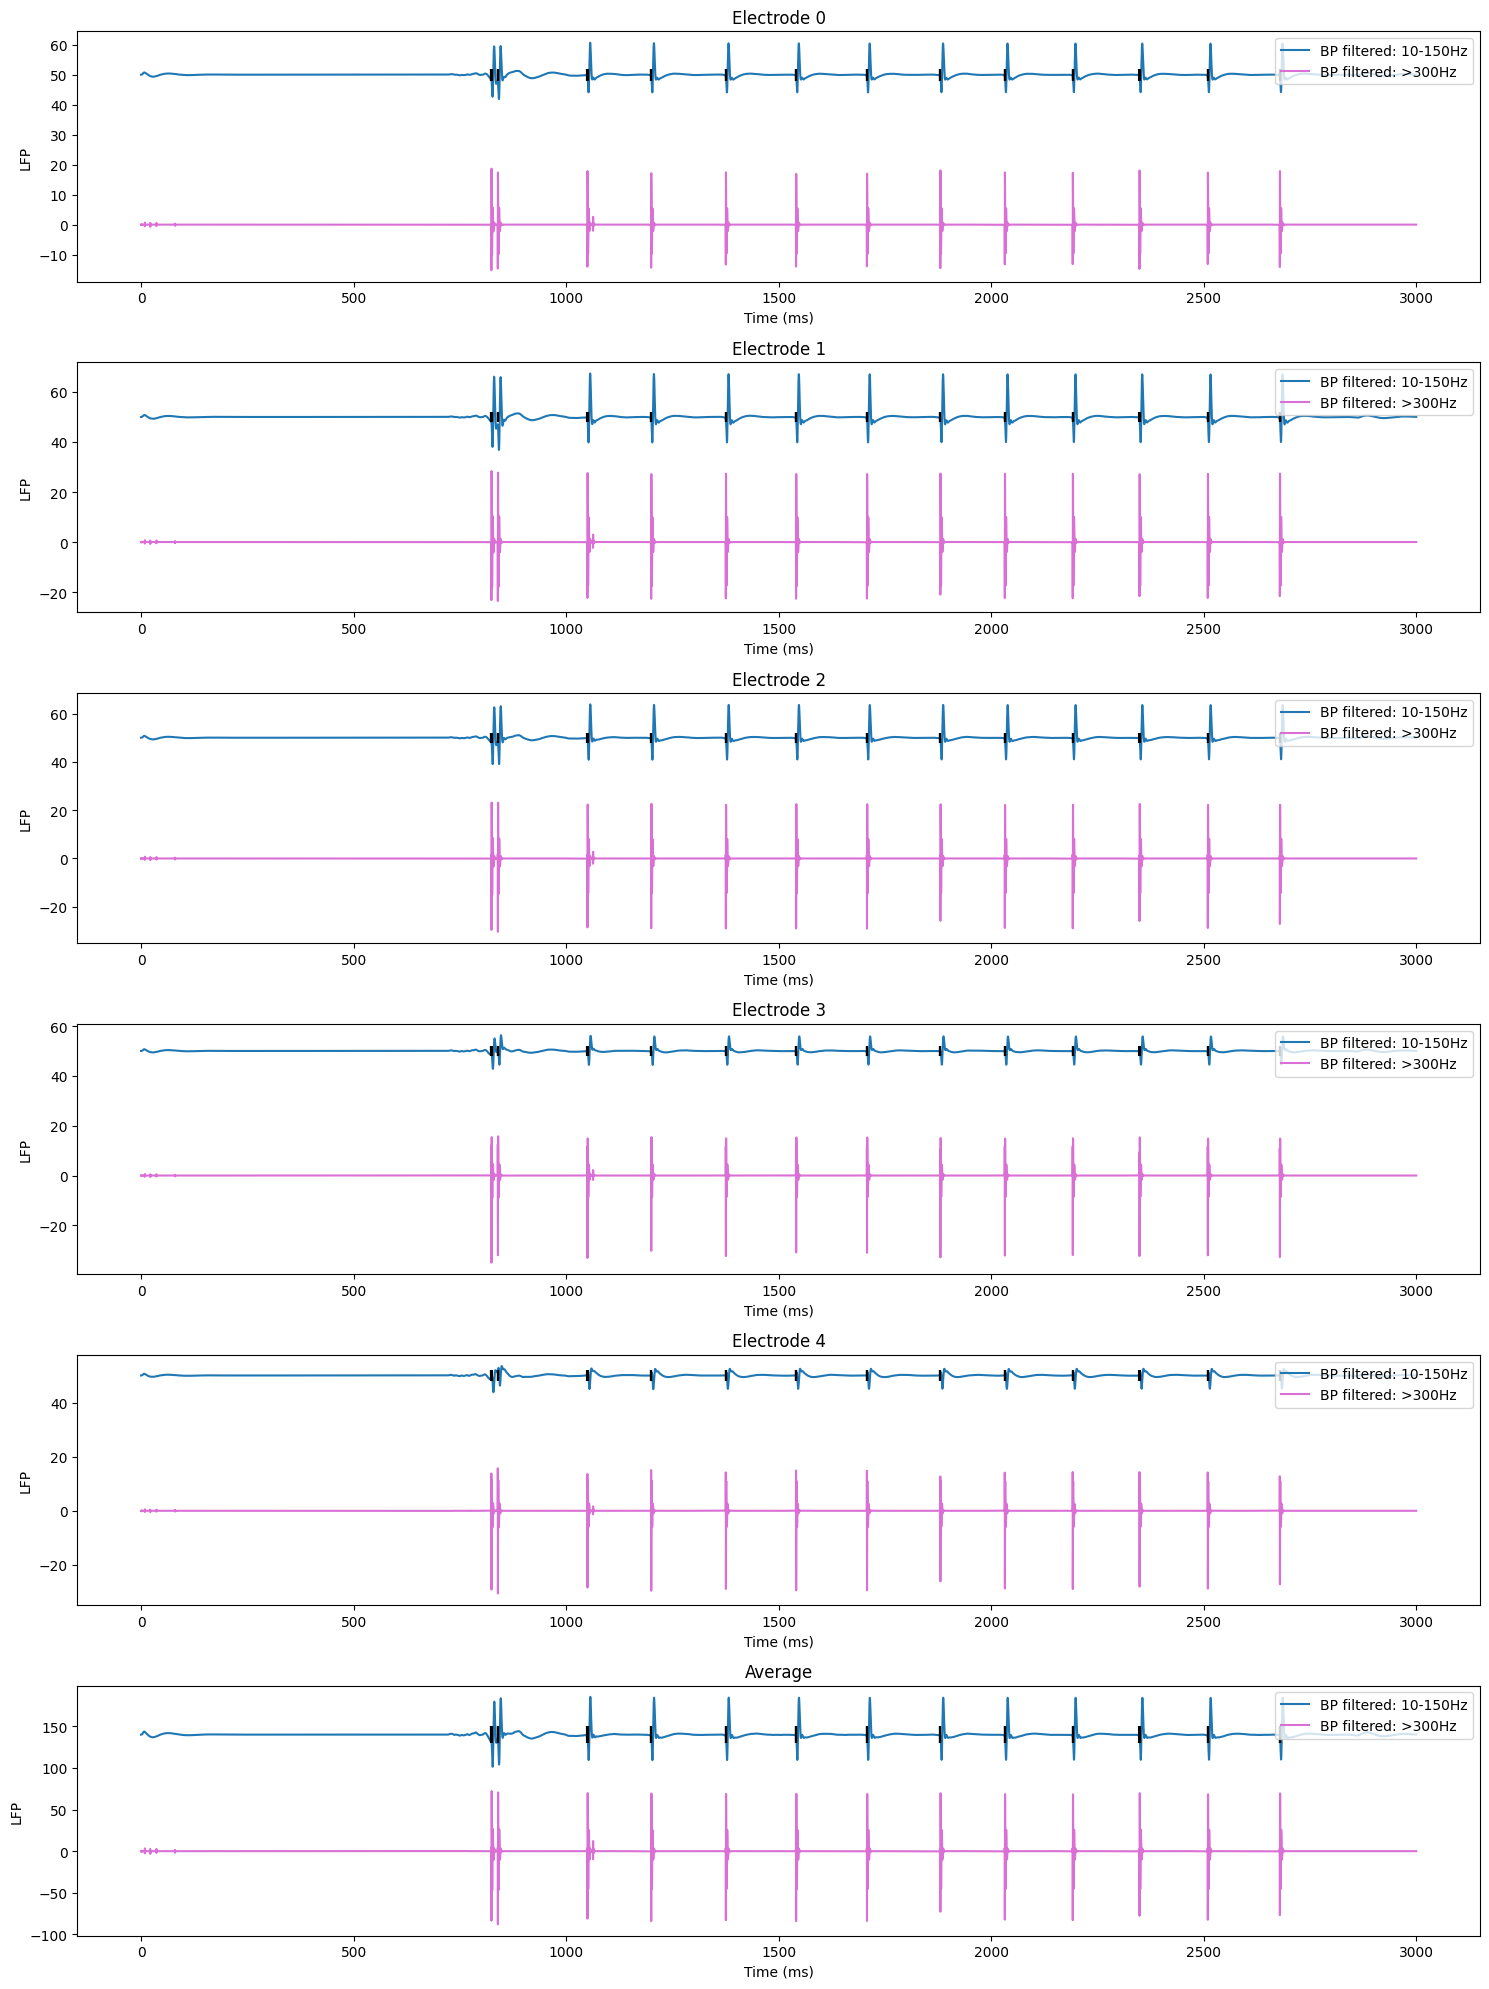

In [19]:
%matplotlib inline
t = list(simData['t'])
dt = 0.1
depths = 5

lfp_lowcut = 10
lfp_highcut = 150
spikes_lowcut = 300
spikes_highcut = 3000
fs = 1/dt*1000

fig, ax = plt.subplots(depths+1, 1, figsize=(15,20))
ax.ravel()

shift = 50
for i in range(0,depths):

    lfp = simData['LFP'][:,i]
    lfp_bp_low = butter_bandpass_filter(lfp, lfp_lowcut, lfp_highcut, fs, order=4)
    lfp_bp_spikes = butter_bandpass_filter(lfp, spikes_lowcut, spikes_highcut, fs, order=4)

    ax[i].plot(t[0:len(lfp_bp_low)],lfp_bp_low*10000+shift,label=f'BP filtered: {lfp_lowcut}-{lfp_highcut}Hz')
    ax[i].plot(t[0:len(lfp_bp_spikes)],lfp_bp_spikes*10000,color='orchid',label=f'BP filtered: >{spikes_lowcut}Hz')
    ax[i].vlines(t_spikes, [shift-2], [shift+2], 'k')
    ax[i].legend(loc='upper right')     
    ax[i].set_title(f'Electrode {i}')
    # ax[i].set_yticks([])
    ax[i].set_xlabel('Time (ms)')
    ax[i].set_ylabel('LFP') 

avg_shift = 140
avg_lfp = np.sum(simData['LFP'],axis=1)
avg_lfp_bp_low = butter_bandpass_filter(avg_lfp, lfp_lowcut, lfp_highcut, fs, order=4)
avg_lfp_bp_spikes = butter_bandpass_filter(avg_lfp, spikes_lowcut, spikes_highcut, fs, order=4)
ax[-1].plot(t[0:len(avg_lfp_bp_low)],avg_lfp_bp_low*10000+avg_shift,label=f'BP filtered: {lfp_lowcut}-{lfp_highcut}Hz')
ax[-1].plot(t[0:len(avg_lfp_bp_spikes)],avg_lfp_bp_spikes*10000,color='orchid',label=f'BP filtered: >{spikes_lowcut}Hz')
ax[-1].vlines(t_spikes, [avg_shift-10], [avg_shift+10], 'k')
ax[-1].legend(loc='upper right')     
ax[-1].set_title(f'Average')
# ax[-1].set_yticks([])
ax[-1].set_xlabel('Time (ms)')
ax[-1].set_ylabel('LFP') 


# fig.suptitle('LFPs')
fig.tight_layout()
fig.savefig(os.path.join(output_dir,'lfps-all_electrodes.png'),bbox_inches='tight',dpi=300)

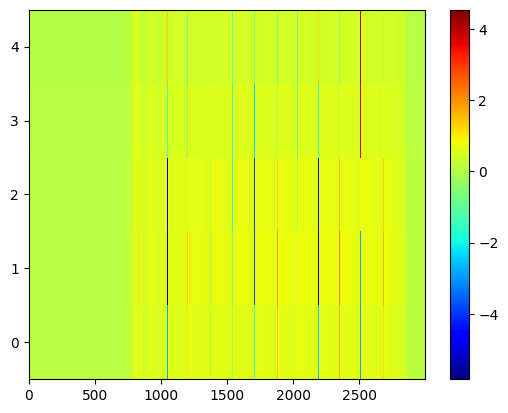

In [15]:
# plt.contourf(t[0:lfp.shape[0]],range(0,depths),simData['LFP'].transpose(),256,cmap='jet')
plt.pcolormesh(t[0:lfp.shape[0]],range(0,depths),simData['LFP'].transpose()*1000,cmap='jet')
plt.colorbar()
# plt.vlines(t_spikes, [1.5], [2], 'k')

### ??

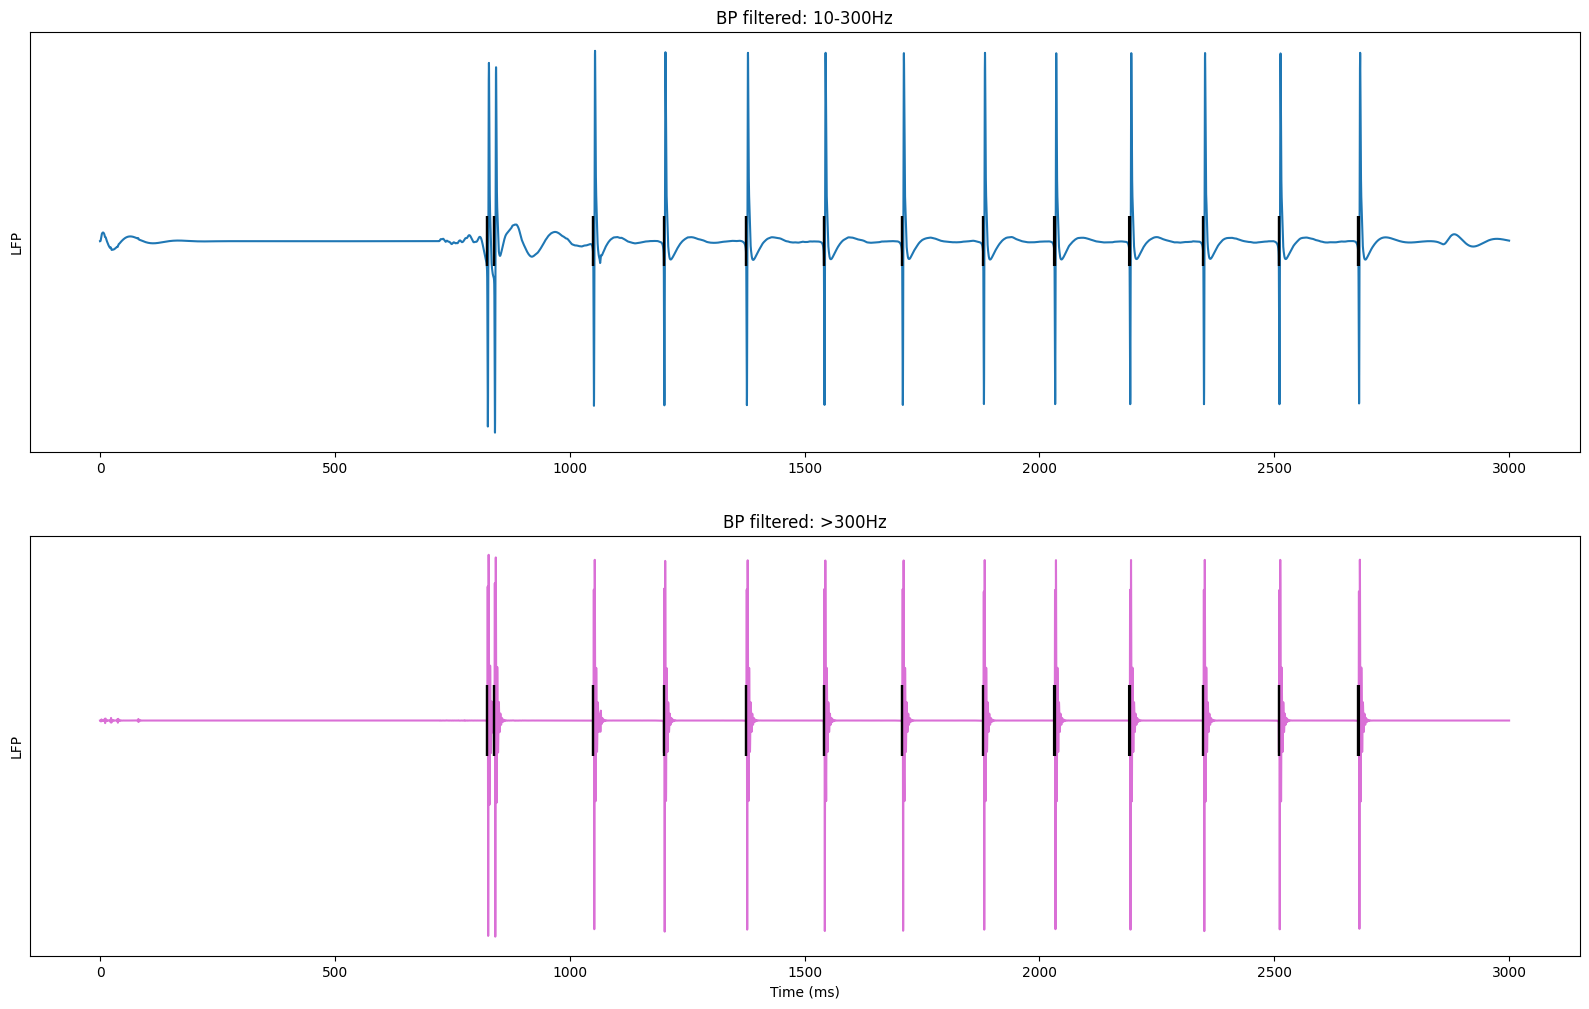

In [136]:
%matplotlib inline
fig, ax = plt.subplots(2, 1, figsize=(20,12))
ax.ravel()

ax[0].plot(t[0:len(lfp_bp_low)],lfp_bp_low*10000,label='BP filtered: 10-300Hz')
ax[0].vlines(t_spikes, [-2], [2], 'k')
ax[0].set_yticks([])
ax[0].set_title('BP filtered: 10-300Hz')
ax[0].set_ylabel('LFP')      

ax[1].plot(t[0:len(lfp_bp_spikes)],lfp_bp_spikes*10000,color='orchid',label='BP filtered: >300Hz')
ax[1].vlines(t_spikes, [-2], [2], 'k')
# ax.legend(loc='upper right')     
ax[1].set_title('BP filtered: >300Hz')
ax[1].set_yticks([])
ax[1].set_xlabel('Time (ms)')
ax[1].set_ylabel('LFP')      
# ax.set_title('LFPs')
# fig.show()
fig.savefig(os.path.join(output_dir,'lfps-order_4.png'),bbox_inches='tight',dpi=300)

In [27]:

### Signal processing ###
def butter_bandpass(lowcut, highcut, fs, order=5):
 nyq = 0.5 * fs
 low = lowcut / nyq
 high = highcut / nyq
 b, a = butter(order, [low, high], btype='band')
 return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
   b, a = butter_bandpass(lowcut, highcut, fs, order=order)
   y = lfilter(b, a, data)
   return y

In [135]:
lfp = [lfp_d[0] for lfp_d in simData['LFP']]
lfp_bp_low = butter_bandpass_filter(lfp, 10, 300, 1/0.1*1000, order=4)

lfp_bp_spikes = butter_bandpass_filter(lfp, 301, 700, 1/0.1*1000, order=4)

In [39]:
1/0.01*100

10000.0

In [22]:
def plot_lfp(t, lfp, t_spikes, dt, output_dir):
    # t = list(simData['t'])
    # spkt = list(simData['spkt'])
    # # lfp_0 = [lfp_d[0] for lfp_d in simData['LFP'][:,0]]
    # lfp = simData['LFP'][:,0]

    lfp_bp_low = butter_bandpass_filter(lfp, 10, 300, 1/dt*1000, order=4)
    lfp_bp_spikes = butter_bandpass_filter(lfp, 301, 700, 1/dt*1000, order=4)

    fig, ax = plt.subplots(2, 1, figsize=(20,12))
    ax.ravel()

    ax[0].plot(t[0:len(lfp_bp_low)],lfp_bp_low*10000,label='BP filtered: 10-300Hz')
    ax[0].vlines(t_spikes, [-2], [2], 'k')
    ax[0].set_yticks([])
    ax[0].set_title('BP filtered: 10-300Hz')
    ax[0].set_ylabel('LFP')      

    ax[1].plot(t[0:len(lfp_bp_spikes)],lfp_bp_spikes*10000,color='orchid',label='BP filtered: >300Hz')
    ax[1].vlines(t_spikes, [-2], [2], 'k')
    # ax.legend(loc='upper right')     
    ax[1].set_title('BP filtered: >300Hz')
    ax[1].set_yticks([])
    ax[1].set_xlabel('Time (ms)')
    ax[1].set_ylabel('LFP')   
    # fig.show()   

    return fig

    # fig.savefig(os.path.join(output_dir,'lfp_fig.png'),bbox_inches='tight',dpi=300)

In [23]:
fig = plot_lfp(list(simData['t']), simData['LFP'][:,0],t_spikes,0.1,output_dir)
fig.show()

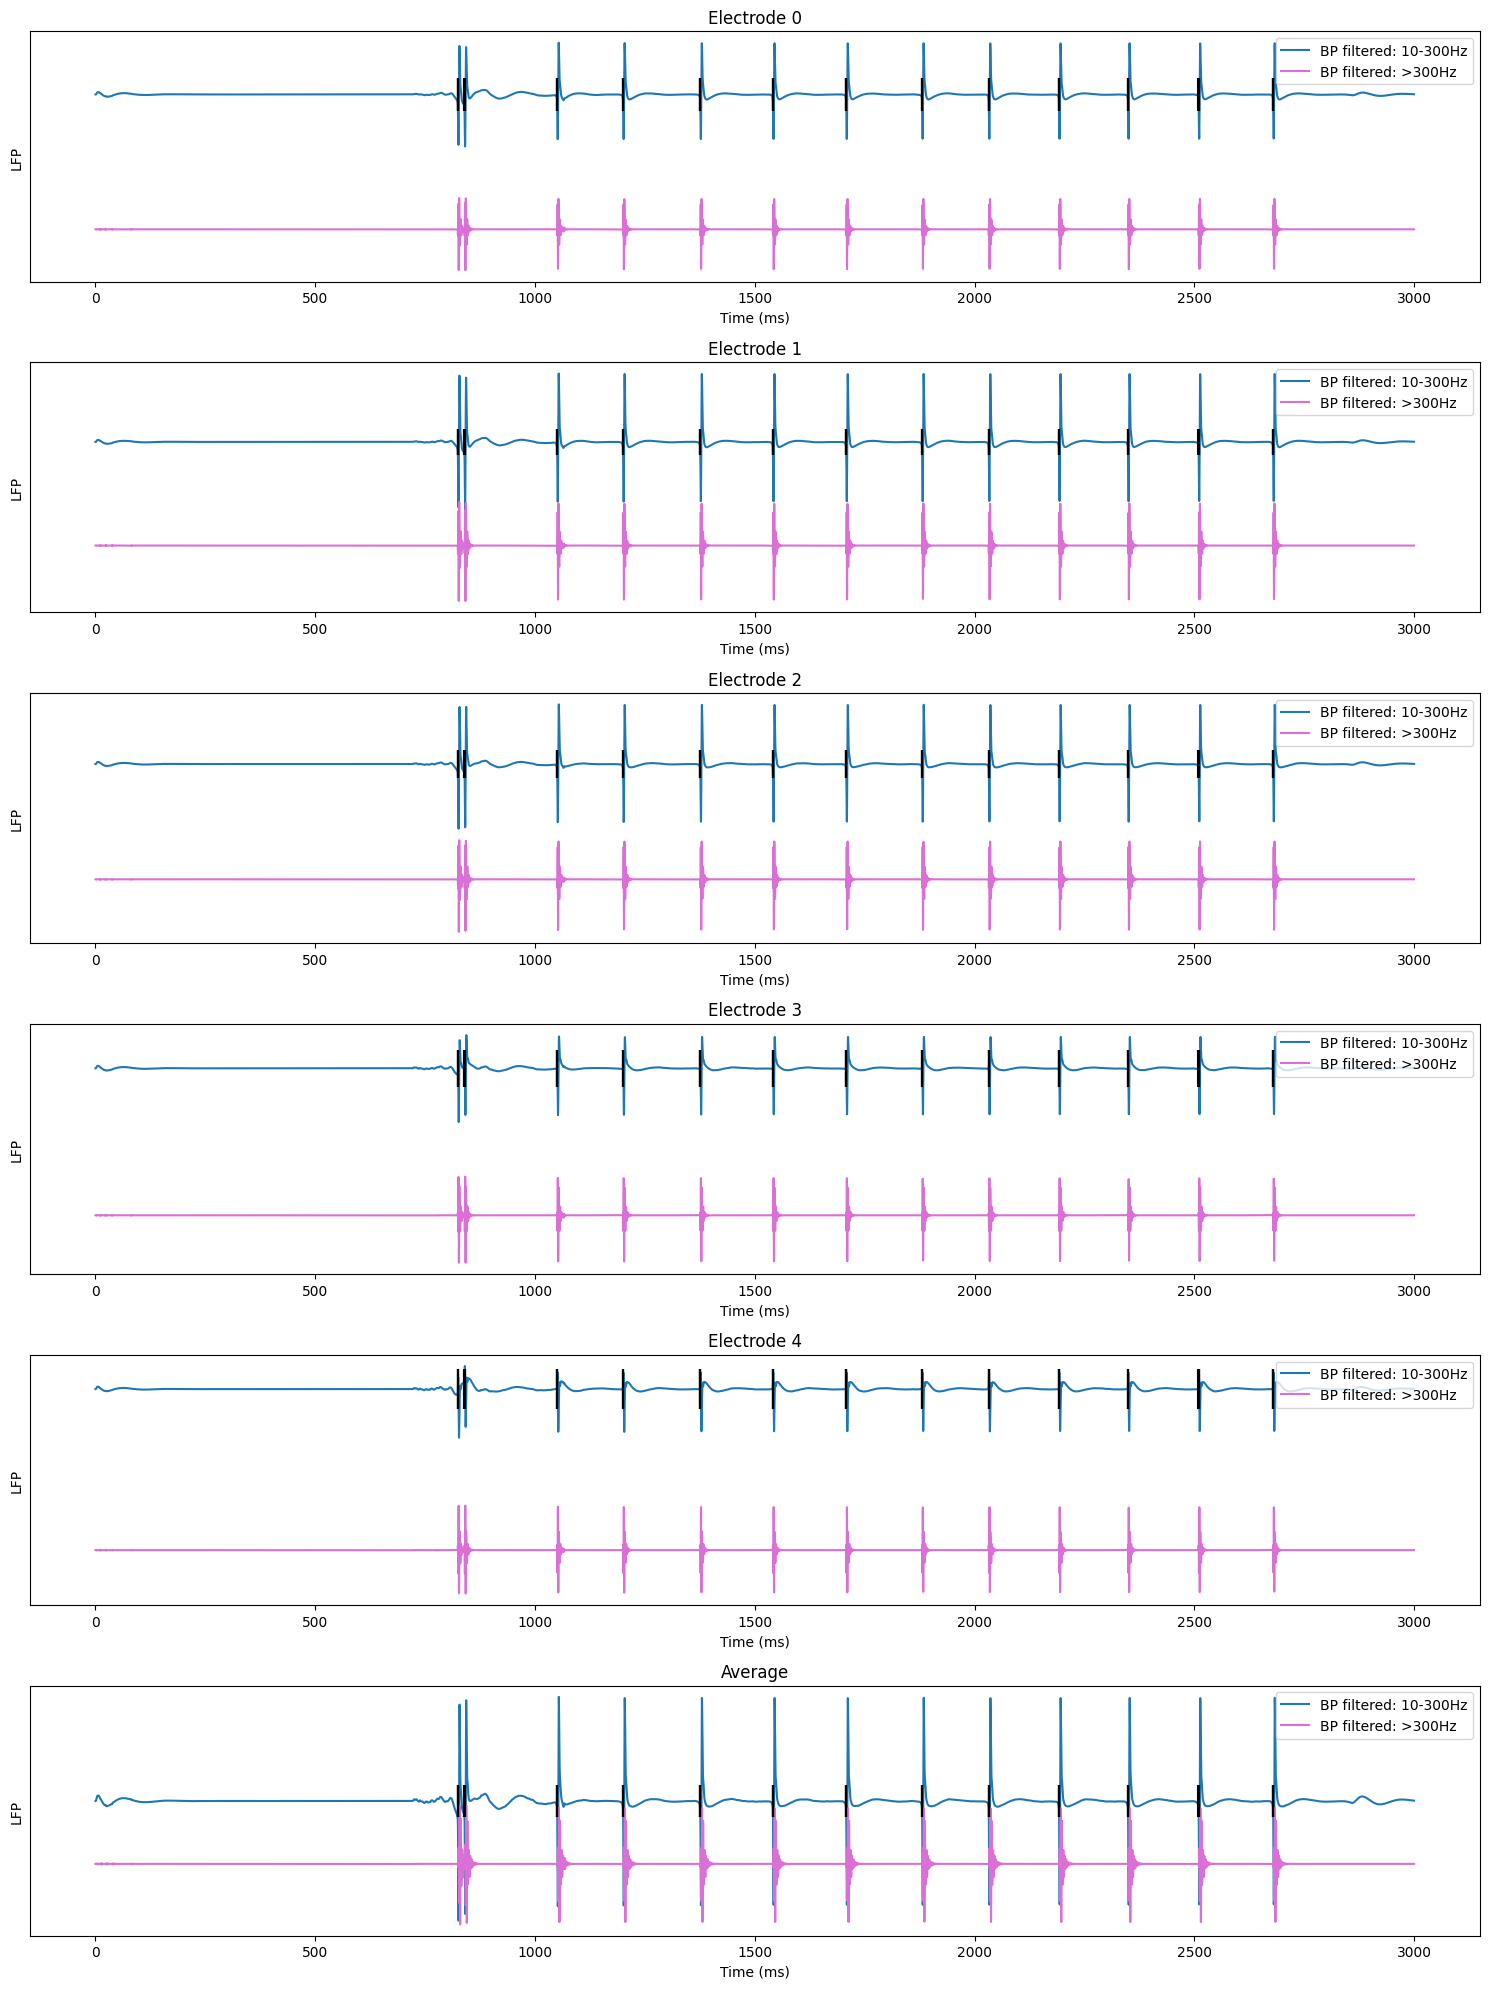

In [10]:
%matplotlib inline
t = list(simData['t'])
dt = 0.1
depths = 5

fig, ax = plt.subplots(depths+1, 1, figsize=(15,20))
ax.ravel()

for i in range(0,depths):

    lfp = simData['LFP'][:,i]
    lfp_bp_low = butter_bandpass_filter(lfp, 10, 300, 1/dt*1000, order=4)
    lfp_bp_spikes = butter_bandpass_filter(lfp, 301, 700, 1/dt*1000, order=4)

    ax[i].plot(t[0:len(lfp_bp_low)],lfp_bp_low*10000+40,label='BP filtered: 10-300Hz')
    ax[i].plot(t[0:len(lfp_bp_spikes)],lfp_bp_spikes*10000,color='orchid',label='BP filtered: >300Hz')
    ax[i].vlines(t_spikes, [35], [45], 'k')
    ax[i].legend(loc='upper right')     
    ax[i].set_title(f'Electrode {i}')
    ax[i].set_yticks([])
    ax[i].set_xlabel('Time (ms)')
    ax[i].set_ylabel('LFP') 

avg_lfp = np.sum(simData['LFP'],axis=1)
avg_lfp_bp_low = butter_bandpass_filter(avg_lfp, 10, 300, 1/dt*1000, order=4)
avg_lfp_bp_spikes = butter_bandpass_filter(avg_lfp, 300, 500, 1/dt*1000, order=4)
ax[-1].plot(t[0:len(avg_lfp_bp_low)],avg_lfp_bp_low*10000+40,label='BP filtered: 10-300Hz')
ax[-1].plot(t[0:len(avg_lfp_bp_spikes)],avg_lfp_bp_spikes*10000,color='orchid',label='BP filtered: >300Hz')
ax[-1].vlines(t_spikes, [30], [50], 'k')
ax[-1].legend(loc='upper right')     
ax[-1].set_title(f'Average')
ax[-1].set_yticks([])
ax[-1].set_xlabel('Time (ms)')
ax[-1].set_ylabel('LFP') 

# fig.suptitle('LFPs')
fig.tight_layout()

In [53]:
lfp = simData['LFP']
lfp.shape[0]
lfp.transpose().shape

(5, 30000)

In [ ]:
wavelet="cgau5"
scale_low=3     # 140 Hz
scale_high=32   # 20 Hz

scales = np.linspace(scale_low/dt, scale_high/dt, 50)     
cfs, frequencies = pywt.cwt(lfp_bp_gamma, scales, wavelet, dt / 1000.0)  # was lfp_bp_gamma
lfp_wavelet_power = np.log(1+abs(cfs))

In [68]:
np.min(lfp)*1000

-5.835938661764073

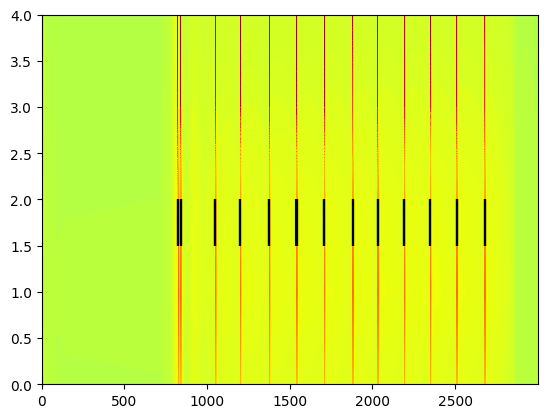

In [70]:
plt.contourf(t[0:lfp.shape[0]],range(0,depths),simData['LFP'].transpose(),256,cmap='jet')
plt.vlines(t_spikes, [1.5], [2], 'k')

In [5]:
def butter_bandpass(lowcut, highcut, fs, order=5):
 nyq = 0.5 * fs
 low = lowcut / nyq
 high = highcut / nyq
 b, a = butter(order, [low, high], btype='band')
 return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
   b, a = butter_bandpass(lowcut, highcut, fs, order=order)
   y = lfilter(b, a, data)
   return y

# lfp_bp_low = butter_bandpass_filter(lfp, 10, 300, 1/0.1*1000, order=4)
# lfp_bp_spikes = butter_bandpass_filter(lfp, 301, 700, 1/0.1*1000, order=4)